In [1]:
import time
import os
import csv
from datetime import datetime
import pandas as pd
import cv2
from ultralytics import YOLO
from IPython.display import display
import matplotlib.pyplot as plt
import plotly.express as px

def shadow_mode(modelo, uconfianza, image_size, csv_ruta):

    # ==========================
    # CONFIGURACIÓN
    # ==========================

    if modelo == 1 and csv_ruta == 1:
        modelo="/home/michell-alvarez/Descargas/best_8n.pt"
        csv_ruta="/home/michell-alvarez/Descargas/zona_segura/sprint5/resultados_ms_zona_segura_8n.csv"
        modelo_elegido= "YOLOv8n"

    else: 
        modelo="/home/michell-alvarez/Descargas/best_8x.pt"    
        csv_ruta="/home/michell-alvarez/Descargas/zona_segura/sprint5/resultados_ms_zona_segura_8x.csv"
        modelo_elegido= "YOLOv8x"     

    # Rutas a tus modelos entrenados
    MODEL_N_PATH = modelo

    # Umbral de confianza
    CONF_THRESHOLD = uconfianza
    IMG_SIZE = image_size

    # Cómo identificar la clase "arma"
    # Opción 1: por índice de clase (ej: si solo tienes 1 clase "gun", suele ser 0)
    ARMA_CLASS_ID = 3

    # Opción 2 (si quieres por nombre):
    # Asegúrate que el nombre de la clase en tu modelo sea exactamente éste.
    ARMA_CLASS_NAME = "pistol"  # cámbialo si tu clase se llama distinto, por ejemplo "arma"

    # Ruta del CSV de resultados
    CSV_PATH = csv_ruta

    # Carpeta donde están los videos de zona segura
    VIDEOS_DIR = "/home/michell-alvarez/Descargas/zona_segura/sprint5"  # <-- CAMBIA ESTA RUTA
    EXTENSIONES_VALIDAS = (".mp4", ".avi", ".mov", ".mkv")  # puedes agregar más


    # ==========================
    # FUNCIONES AUXILIARES
    # ==========================

    def contar_falsos_positivos(result, usar_nombre=True):
        """
        Cuenta cuántas detecciones corresponden a 'arma'
        en un frame, que en zona segura se consideran FALSOS POSITIVOS.
        """
        fp = 0
        boxes = result.boxes

        if boxes is None:
            return 0

        cls = boxes.cls.cpu().numpy()

        if usar_nombre and hasattr(result, "names"):
            names = result.names
            for c in cls:
                nombre_clase = names[int(c)]
                if nombre_clase == ARMA_CLASS_NAME:
                    fp += 1
        else:
            # Por ID de clase
            for c in cls:
                if int(c) == ARMA_CLASS_ID:
                    fp += 1

        return fp


    def inicializar_metricas():
        return {
            "frames_procesados": 0,
            "suma_latencia_inferencia_ms": 0.0,
            "suma_latencia_total_ms": 0.0,
            "falsos_positivos": 0,
        }


    def calcular_resultados(nombre_modelo, met, duracion_sec):
        fps_promedio = met["frames_procesados"] / duracion_sec if duracion_sec > 0 else 0.0
        latencia_inf_prom = (met["suma_latencia_inferencia_ms"] / met["frames_procesados"]
                            if met["frames_procesados"] > 0 else 0.0)
        latencia_total_prom = (met["suma_latencia_total_ms"] / met["frames_procesados"]
                            if met["frames_procesados"] > 0 else 0.0)
        fp_por_minuto = (met["falsos_positivos"] / (duracion_sec / 60.0)
                        if duracion_sec > 0 else 0.0)

        return {
            "modelo": nombre_modelo,
            "frames_procesados": met["frames_procesados"],
            "duracion_sec": round(duracion_sec, 2),
            "latencia_inferencia_ms": round(latencia_inf_prom, 2),
            "latencia_total_ms": round(latencia_total_prom, 2),
            "fps_promedio": round(fps_promedio, 2),
            "falsos_positivos": met["falsos_positivos"],
            "fp_por_minuto": round(fp_por_minuto, 2),
        }


    def asegurar_csv_con_cabecera(ruta_csv):
        if not os.path.exists(ruta_csv):
            with open(ruta_csv, mode="w", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "timestamp",
                    "video",                 # <-- nueva columna
                    "modelo",
                    "frames_procesados",
                    "duracion_sec",
                    "latencia_inferencia_ms",
                    "latencia_total_ms",
                    "fps_promedio",
                    "falsos_positivos",
                    "fp_por_minuto",
                ])


    def append_resultado_csv(ruta_csv, resultado, nombre_video):
        with open(ruta_csv, mode="a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(timespec="seconds"),
                nombre_video,
                resultado["modelo"],
                resultado["frames_procesados"],
                resultado["duracion_sec"],
                resultado["latencia_inferencia_ms"],
                resultado["latencia_total_ms"],
                resultado["fps_promedio"],
                resultado["falsos_positivos"],
                resultado["fp_por_minuto"],
            ])


    # ==========================
    # MAIN: Shadow Mode ZONA SEGURA (VIDEOS)
    # ==========================

    def main():
        # Cargar modelos
        print("Cargando modelo..." + modelo_elegido)
        model_n = YOLO(MODEL_N_PATH)

        # Asegurar CSV con cabecera
        asegurar_csv_con_cabecera(CSV_PATH)

        # Verificar carpeta de videos
        if not os.path.isdir(VIDEOS_DIR):
            print(f"La carpeta de videos no existe: {VIDEOS_DIR}")
            return

        videos = sorted([
            f for f in os.listdir(VIDEOS_DIR)
            if f.lower().endswith(EXTENSIONES_VALIDAS)
        ])

        if not videos:
            print(f"No se encontraron videos en {VIDEOS_DIR} con extensiones {EXTENSIONES_VALIDAS}")
            return

        print("=== Shadow Mode -- ZONA SEGURA (VIDEOS) ===")

        # Procesar cada video de la carpeta
        for video_name in videos:
            video_path = os.path.join(VIDEOS_DIR, video_name)
            print(f"\nProcesando video: {video_name}")
            print(f"Ruta completa: {video_path}")

            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f"No se pudo abrir el video: {video_path}")
                continue

            # Métricas separadas por video y por modelo
            metricas_n = inicializar_metricas()

            start_time = time.time()

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # ==========================
                # MODELO N
                # ==========================
                t_total_start_n = time.time()
                t_inf_start_n = time.time()
                results_n = model_n.predict(
                    frame,
                    conf=CONF_THRESHOLD,
                    imgsz=IMG_SIZE,
                    verbose=False
                )
                t_inf_end_n = time.time()

                r_n = results_n[0]
                fp_n = contar_falsos_positivos(r_n, usar_nombre=True)

                t_total_end_n = time.time()

                metricas_n["frames_procesados"] += 1
                metricas_n["falsos_positivos"] += fp_n
                metricas_n["suma_latencia_inferencia_ms"] += (t_inf_end_n - t_inf_start_n) * 1000.0
                metricas_n["suma_latencia_total_ms"] += (t_total_end_n - t_total_start_n) * 1000.0


            end_time = time.time()
            duracion_sec = end_time - start_time

            cap.release()
            # cv2.destroyAllWindows()  # solo si usas imshow

            # Calcular resultados finales por modelo para este video
            resultado_n = calcular_resultados(modelo_elegido, metricas_n, duracion_sec)

            print("\n--- RESULTADOS ZONA SEGURA PARA ESTE VIDEO ---")
            for res in [resultado_n]:
                print(f"\nVideo:              {video_name}")
                print(f"Modelo:             {res['modelo']}")
                print(f"Frames procesados:  {res['frames_procesados']}")
                print(f"Duración total [s]: {res['duracion_sec']}")
                print(f"Latencia inf [ms]:  {res['latencia_inferencia_ms']}")
                print(f"Latencia total [ms]:{res['latencia_total_ms']}")
                print(f"FPS promedio:       {res['fps_promedio']}")
                print(f"Falsos positivos:   {res['falsos_positivos']}")
                print(f"FP por minuto:      {res['fp_por_minuto']}")

            # Guardar resultados en CSV (una fila por modelo y video)
            append_resultado_csv(CSV_PATH, resultado_n, video_name)

        print(f"\nProcesamiento terminado. Resultados guardados en: {CSV_PATH}")

    if __name__ == "__main__":
        main()

    # Al finalizar
    df = pd.read_csv(CSV_PATH)
    return df

In [ ]:
df_zona_segura_baseline = shadow_mode(1, 0.5, 640, 1)

Cargando modelo...YOLOv8n
=== Shadow Mode -- ZONA SEGURA (VIDEOS) ===

Procesando video: 01_Zona_Segura_Sin_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_segura/sprint5/01_Zona_Segura_Sin_Arma.mp4

--- RESULTADOS ZONA SEGURA PARA ESTE VIDEO ---

Video:              01_Zona_Segura_Sin_Arma.mp4
Modelo:             YOLOv8n
Frames procesados:  917
Duración total [s]: 7.95
Latencia inf [ms]:  8.48
Latencia total [ms]:8.52
FPS promedio:       115.4
Falsos positivos:   1
FP por minuto:      7.55

Procesando video: 02_Zona_Segura_Sin_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_segura/sprint5/02_Zona_Segura_Sin_Arma.mp4

--- RESULTADOS ZONA SEGURA PARA ESTE VIDEO ---

Video:              02_Zona_Segura_Sin_Arma.mp4
Modelo:             YOLOv8n
Frames procesados:  377
Duración total [s]: 1.84
Latencia inf [ms]:  4.73
Latencia total [ms]:4.77
FPS promedio:       204.57
Falsos positivos:   0
FP por minuto:      0.0

Procesando video: 03_Zona_Segura_Sin_Arma.mp4
Ruta 

In [ ]:
df_zona_segura_actual = shadow_mode(2, 0.5, 640, 2)

Cargando modelo...YOLOv8x
=== Shadow Mode -- ZONA SEGURA (VIDEOS) ===

Procesando video: 01_Zona_Segura_Sin_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_segura/sprint5/01_Zona_Segura_Sin_Arma.mp4

--- RESULTADOS ZONA SEGURA PARA ESTE VIDEO ---

Video:              01_Zona_Segura_Sin_Arma.mp4
Modelo:             YOLOv8x
Frames procesados:  917
Duración total [s]: 33.75
Latencia inf [ms]:  36.39
Latencia total [ms]:36.47
FPS promedio:       27.17
Falsos positivos:   0
FP por minuto:      0.0

Procesando video: 02_Zona_Segura_Sin_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_segura/sprint5/02_Zona_Segura_Sin_Arma.mp4

--- RESULTADOS ZONA SEGURA PARA ESTE VIDEO ---

Video:              02_Zona_Segura_Sin_Arma.mp4
Modelo:             YOLOv8x
Frames procesados:  377
Duración total [s]: 13.49
Latencia inf [ms]:  35.39
Latencia total [ms]:35.46
FPS promedio:       27.94
Falsos positivos:   0
FP por minuto:      0.0

Procesando video: 03_Zona_Segura_Sin_Arma.mp4
R

In [4]:
def resumen_zona_segura(df: pd.DataFrame, nombre: str):
    resumen = {}

    # --- Latencia (usamos latencia_total_ms como referencia principal) ---
    lat = df["latencia_total_ms"]
    resumen["nombre"] = nombre
    resumen["lat_p50_ms"] = lat.quantile(0.50)
    resumen["lat_p95_ms"] = lat.quantile(0.95)
    resumen["lat_media_ms"] = lat.mean()
    resumen["lat_min_ms"] = lat.min()
    resumen["lat_max_ms"] = lat.max()

    # --- Throughput (FPS) ---
    fps = df["fps_promedio"]
    resumen["fps_promedio_global"] = fps.mean()
    resumen["fps_min"] = fps.min()
    resumen["fps_max"] = fps.max()

    # --- Errores (zona segura) ---
    fp = df["falsos_positivos"]
    resumen["fp_totales"] = fp.sum()
    resumen["fp_min_promedio"] = df["fp_por_minuto"].mean()
    total_videos = len(df)
    videos_con_fp = (fp > 0).sum()
    resumen["videos_con_fp"] = videos_con_fp
    resumen["total_videos"] = total_videos

    return resumen


In [7]:
# Resúmenes
res_baseline = resumen_zona_segura(df_zona_segura_baseline, "YOLOv8n")
res_actual   = resumen_zona_segura(df_zona_segura_actual, "YOLOv8x")

df_resumen = pd.DataFrame([res_baseline, res_actual])

# Redondear a 2 decimales
df_resumen_red = df_resumen.copy()
cols_decimales = [
    "lat_p50_ms", "lat_p95_ms", "lat_media_ms", "lat_min_ms", "lat_max_ms",
    "fps_promedio_global", "fps_min", "fps_max"
]
df_resumen_red[cols_decimales] = df_resumen_red[cols_decimales].round(2)

# --- Tabla de latencia ---
tabla_latencia = df_resumen_red[[
    "nombre",
    "lat_p50_ms",
    "lat_p95_ms",
    "lat_media_ms",
    "lat_min_ms",
    "lat_max_ms"
]].set_index("nombre")

# --- Tabla de throughput ---
tabla_throughput = df_resumen_red[[
    "nombre",
    "fps_promedio_global",
    "fps_min",
    "fps_max"
]].set_index("nombre")

# --- Tabla de errores (zona con arma) ---
tabla_errores = df_resumen_red[[
    "nombre",
    "fp_totales",
    "fp_min_promedio",
    "videos_con_fp",
    "total_videos"
]].set_index("nombre")
			

In [8]:
# --- Redondear a 2 decimales donde aplica ---
tabla_latencia_fmt = tabla_latencia.round(2)
tabla_throughput_fmt = tabla_throughput.round(2)
tabla_errores_fmt = tabla_errores.round(2)

# === Tabla de LATENCIA ===
latencia_styled = (
    tabla_latencia_fmt.style
    .set_caption("Latencia en zona segura (ms)")
    .format("{:.2f}")                      # 2 decimales
    .background_gradient(cmap="Blues")     # degradado azul
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#1f77b4"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)

# === Tabla de THROUGHPUT ===
throughput_styled = (
    tabla_throughput_fmt.style
    .set_caption("Throughput en zona segura (FPS)")
    .format("{:.2f}")
    .background_gradient(cmap="Greens")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2ca02c"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)

# === Tabla de ERRORES ===
errores_styled = (
    tabla_errores_fmt.style
    .set_caption("Errores en zona segura (FP)")
    .format("{:.2f}")
    .background_gradient(cmap="Reds")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#d62728"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)

# Mostrarlas con diseño en Jupyter
display(latencia_styled)
display(throughput_styled)
display(errores_styled)


,lat_p50_ms,lat_p95_ms,lat_media_ms,lat_min_ms,lat_max_ms
nombre,,,,,
YOLOv8n,5.31,8.02,5.54,4.63,8.52
YOLOv8x,34.72,46.32,36.55,32.20,46.38


,fps_promedio_global,fps_min,fps_max
nombre,,,
YOLOv8n,176.38,115.40,209.58
YOLOv8x,27.51,21.42,30.46


,fp_totales,fp_min_promedio,videos_con_fp,total_videos
nombre,,,,
YOLOv8n,5.00,1.94,3.00,40.00
YOLOv8x,4.00,0.29,2.00,40.00


In [15]:
# Construir un DataFrame en formato largo (long format)
df_box = pd.DataFrame({
    "latencia_total_ms": pd.concat([
        df_zona_segura_baseline["latencia_total_ms"],
        df_zona_segura_actual["latencia_total_ms"]
    ], ignore_index=True),
    "modelo": (["YOLOv8n"] * len(df_zona_segura_baseline)) +
              (["YOLOv8x"] * len(df_zona_segura_actual))
})

# Crear boxplot interactivo
fig = px.box(
    df_box,
    x="modelo",
    y="latencia_total_ms",
    title="Distribución de latencias en zona segura",
    labels={
        "modelo": "Tipo de modelo",
        "latencia_total_ms": "Latencia total (ms)"
    }
)

fig.show()

In [16]:
# Unificar datos para Plotly (formato largo)
df_hist = pd.DataFrame({
    "latencia_total_ms": pd.concat([
        df_zona_segura_baseline["latencia_total_ms"],
        df_zona_segura_actual["latencia_total_ms"]
    ], ignore_index=True),
    "modelo": (["YOLOv8n"] * len(df_zona_segura_baseline)) +
              (["YOLOv8x"] * len(df_zona_segura_actual))
})

# Histograma con Plotly
fig = px.histogram(
    df_hist,
    x="latencia_total_ms",
    color="modelo",
    nbins=15,
    barmode="overlay",  # lo deja como Matplotlib (superpuestos)
    opacity=0.5,
    labels={
        "latencia_total_ms": "Latencia total (ms)",
        "modelo": "Tipo de modelo"
    },
    title="Histograma de latencia total - zona segura"
)

fig.show()

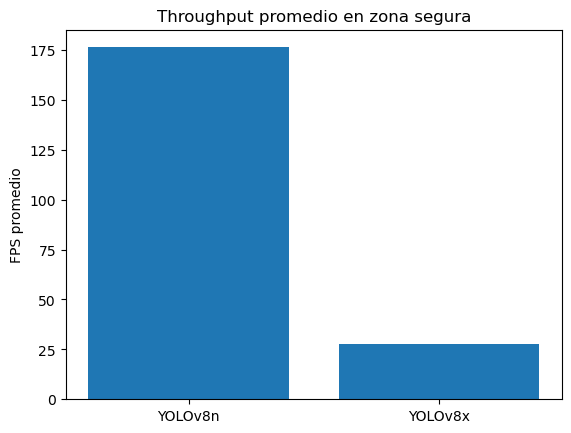

In [17]:
plt.figure()
plt.bar(
    ["YOLOv8n", "YOLOv8x"],
    [res_baseline["fps_promedio_global"], res_actual["fps_promedio_global"]]
)
plt.ylabel("FPS promedio")
plt.title("Throughput promedio en zona segura")
plt.show()


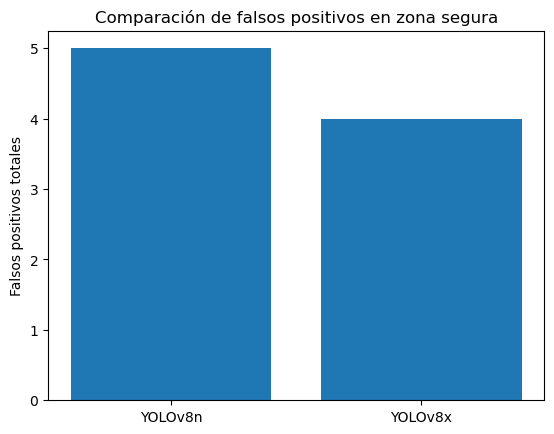

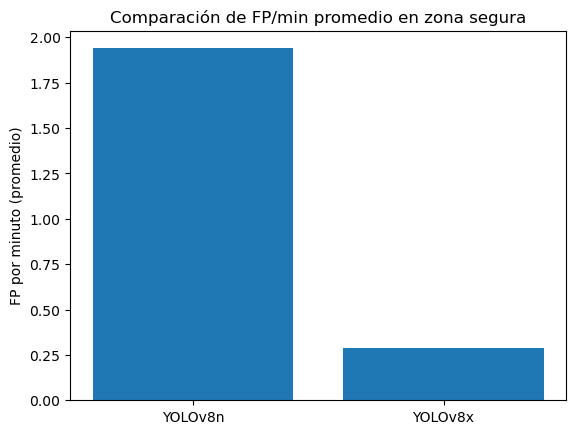

In [18]:
# Falsos positivos totales
plt.figure()
plt.bar(
    ["YOLOv8n", "YOLOv8x"],
    [res_baseline["fp_totales"], res_actual["fp_totales"]]
)
plt.ylabel("Falsos positivos totales")
plt.title("Comparación de falsos positivos en zona segura")
plt.show()

# FP por minuto promedio
plt.figure()
plt.bar(
    ["YOLOv8n", "YOLOv8x"],
    [res_baseline["fp_min_promedio"], res_actual["fp_min_promedio"]]
)
plt.ylabel("FP por minuto (promedio)")
plt.title("Comparación de FP/min promedio en zona segura")
plt.show()

## **Comparativo Baseline vs Actual**

El modelo **baseline (YOLOv8n)** ofrece una latencia extremadamente baja y un throughput muy alto, lo que se traduce en una experiencia visual totalmente fluida para el usuario. Sin embargo, presenta un mayor número de falsos positivos, lo que reduce la confiabilidad operativa.  
Por otro lado, el **modelo actual (YOLOv8x)** es más pesado y presenta mayor latencia, pero mantiene un desempeño estable en tiempo real y reduce significativamente los falsos positivos, brindando una percepción de mayor precisión y menor ruido en las alertas.  
El baseline es más rápido, mientras que el modelo actual es más confiable para el operador en un entorno real.

---

## **Latencia, throughput, errores y optimizaciones**

El análisis técnico muestra que el modelo actual incrementa la latencia (p50/p95) y reduce los FPS respecto al baseline, aunque se mantiene dentro de niveles aceptables para la operación en tiempo real. Asimismo, mejora el control de errores al disminuir los falsos positivos.  
En conjunto, el sistema actual ofrece un equilibrio funcional entre velocidad y confiabilidad, lo que lo hace adecuado para su aplicación en escenarios operativos y pruebas en campo.

In [13]:
def shadow_mode_zona_con_arma(modelo, uconfianza, image_size, csv_ruta):

    # ==========================
    # CONFIGURACIÓN
    # ==========================

    if modelo == 1 and csv_ruta == 1:
        modelo="/home/michell-alvarez/Descargas/best_8n.pt"
        csv_ruta="/home/michell-alvarez/Descargas/zona_peligrosa/sprint5/resultados_ms_zona_con_arma_8n.csv"
        modelo_elegido= "YOLOv8n"
        #image_size=640
    else: 
        modelo="/home/michell-alvarez/Descargas/best_8x.pt"    
        csv_ruta="/home/michell-alvarez/Descargas/zona_peligrosa/sprint5/resultados_ms_zona_con_arma_8x.csv"
        modelo_elegido= "YOLOv8x"     
        #image_size=640


    # Rutas a tus modelos entrenados
    MODEL_N_PATH = modelo

    # Umbral de confianza
    CONF_THRESHOLD = uconfianza
    IMG_SIZE = image_size
        

    # Cómo identificar la clase "arma"
    # Opción 1: por índice de clase (ej: si solo tienes 1 clase "gun", suele ser 0)
    ARMA_CLASS_ID = 3

    # Opción 2 (si quieres por nombre):
    # Asegúrate que el nombre de la clase en tu modelo sea exactamente éste.
    ARMA_CLASS_NAME = "pistol"  # cámbialo si tu clase se llama distinto, por ejemplo "arma"

    USAR_NOMBRE_CLASE = True  # True = usa ARMA_CLASS_NAME, False = usa ARMA_CLASS_ID

    # Ruta del CSV de resultados
    CSV_PATH = csv_ruta

    # Carpeta donde están los videos a evaluar
    VIDEOS_DIR = "/home/michell-alvarez/Descargas/zona_peligrosa/sprint5"  # ← CAMBIA ESTO A TU RUTA
    EXTENSIONES_VALIDAS = (".mp4", ".avi", ".mov", ".mkv")  # puedes agregar más si quieres


    # ==========================
    # FUNCIONES AUXILIARES
    # ==========================

    def contar_detecciones_arma(result):
        """
        Cuenta cuántas detecciones corresponden a 'arma'
        en un frame. En este escenario, asumimos que
        cualquier detección de esa clase es un "hit" (detección de arma).
        """
        boxes = result.boxes
        if boxes is None:
            return 0

        cls = boxes.cls.cpu().numpy()
        num_dets = 0

        if USAR_NOMBRE_CLASE and hasattr(result, "names"):
            names = result.names
            for c in cls:
                nombre_clase = names[int(c)]
                if nombre_clase == ARMA_CLASS_NAME:
                    num_dets += 1
        else:
            for c in cls:
                if int(c) == ARMA_CLASS_ID:
                    num_dets += 1

        return num_dets


    def inicializar_metricas():
        return {
            "frames_procesados": 0,
            "suma_latencia_inferencia_ms": 0.0,
            "suma_latencia_total_ms": 0.0,
            "frames_con_arma": 0,  # frames donde hubo al menos 1 detección de arma
        }


    def calcular_resultados(nombre_modelo, met, duracion_sec):
        frames = met["frames_procesados"]
        fps_promedio = frames / duracion_sec if duracion_sec > 0 else 0.0

        latencia_inf_prom = (met["suma_latencia_inferencia_ms"] / frames
                            if frames > 0 else 0.0)
        latencia_total_prom = (met["suma_latencia_total_ms"] / frames
                            if frames > 0 else 0.0)


        # Escenario: este video se considera "con arma"
        tp_video = 1 if met["frames_con_arma"] > 0 else 0
        recall_video = float(tp_video)  # 1.0 si detecta al menos una vez, 0.0 si no

        return {
            "modelo": nombre_modelo,
            "frames_procesados": frames,
            "duracion_sec": round(duracion_sec, 2),
            "latencia_inferencia_ms": round(latencia_inf_prom, 2),
            "latencia_total_ms": round(latencia_total_prom, 2),
            "fps_promedio": round(fps_promedio, 2),
            "frames_con_arma": met["frames_con_arma"],
            "tp_video": tp_video,
            "recall_video": recall_video,
        }


    def asegurar_csv_con_cabecera(ruta_csv):
        if not os.path.exists(ruta_csv):
            with open(ruta_csv, mode="w", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "timestamp",
                    "video",                  # ← NUEVA COLUMNA
                    "modelo",
                    "frames_procesados",
                    "duracion_sec",
                    "latencia_inferencia_ms",
                    "latencia_total_ms",
                    "fps_promedio",
                    "frames_con_arma",
                    "tp_video",
                    "recall_video",
                ])


    def append_resultado_csv(ruta_csv, resultado, nombre_video):
        with open(ruta_csv, mode="a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(timespec="seconds"),
                nombre_video,  # ← para saber a qué video corresponde
                resultado["modelo"],
                resultado["frames_procesados"],
                resultado["duracion_sec"],
                resultado["latencia_inferencia_ms"],
                resultado["latencia_total_ms"],
                resultado["fps_promedio"],
                resultado["frames_con_arma"],
                resultado["tp_video"],
                resultado["recall_video"],
            ])


    # ==========================
    # MAIN: Shadow Mode ZONA PELIGROSA CONTROLADA (VIDEOS)
    # ==========================

    def main():
        # Cargar modelos
        print("Cargando modelo..." + modelo_elegido)
        model_n = YOLO(MODEL_N_PATH)


        # Aseguramos el CSV con cabecera
        asegurar_csv_con_cabecera(CSV_PATH)

        # Listar videos en la carpeta
        if not os.path.isdir(VIDEOS_DIR):
            print(f"La carpeta de videos no existe: {VIDEOS_DIR}")
            return

        videos = sorted([
            f for f in os.listdir(VIDEOS_DIR)
            if f.lower().endswith(EXTENSIONES_VALIDAS)
        ])

        if not videos:
            print(f"No se encontraron videos en {VIDEOS_DIR} con extensiones {EXTENSIONES_VALIDAS}")
            return

        print("=== Shadow Mode -- ZONA CON PRESENCIA DE ARMA (VIDEOS) ===")
        print(f"Carpeta: {VIDEOS_DIR}")
        print(f"Videos encontrados: {len(videos)}\n")

        for video_name in videos:
            video_path = os.path.join(VIDEOS_DIR, video_name)
            print(f"\nProcesando video: {video_name}")
            print(f"Ruta completa: {video_path}")

            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f"No se pudo abrir el video: {video_path}")
                continue

            # Métricas separadas por video y por modelo
            metricas_n = inicializar_metricas()

            start_time = time.time()

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # ==========================
                # MODELO N
                # ==========================
                t_total_start_n = time.time()
                t_inf_start_n = time.time()
                results_n = model_n.predict(
                    frame,
                    conf=CONF_THRESHOLD,
                    imgsz=IMG_SIZE,
                    verbose=False
                )
                t_inf_end_n = time.time()

                r_n = results_n[0]
                num_dets_n = contar_detecciones_arma(r_n)
                t_total_end_n = time.time()

                metricas_n["frames_procesados"] += 1
                if num_dets_n > 0:
                    metricas_n["frames_con_arma"] += 1

                metricas_n["suma_latencia_inferencia_ms"] += (t_inf_end_n - t_inf_start_n) * 1000.0
                metricas_n["suma_latencia_total_ms"] += (t_total_end_n - t_total_start_n) * 1000.0


            end_time = time.time()
            duracion_sec = end_time - start_time

            cap.release()
            # cv2.destroyAllWindows()  # solo si usas imshow

            # Calcular resultados finales por video
            resultado_n = calcular_resultados(modelo_elegido, metricas_n, duracion_sec)

            print("\n--- RESULTADOS ZONA CON ARMA PARA ESTE VIDEO ---")
            for res in [resultado_n]:
                print(f"\nVideo:  {video_name}")
                print(f"Modelo: {res['modelo']}")
                print(f"Frames procesados:          {res['frames_procesados']}")
                print(f"Duración total [s]:         {res['duracion_sec']}")
                print(f"Latencia inf [ms]:          {res['latencia_inferencia_ms']}")
                print(f"Latencia total [ms]:        {res['latencia_total_ms']}")
                print(f"FPS promedio:               {res['fps_promedio']}")
                print(f"Frames con arma detectada:  {res['frames_con_arma']}")
                print(f"TP_video:                   {res['tp_video']}")
                print(f"Recall a nivel video:       {res['recall_video']}")

            # Guardar resultados en CSV (una fila por modelo y video)
            append_resultado_csv(CSV_PATH, resultado_n, video_name)

        print(f"\nProcesamiento terminado. Resultados guardados en: {CSV_PATH}")


    if __name__ == "__main__":
        main()

    # Al finalizar
    df = pd.read_csv(CSV_PATH)
    return df

In [19]:
df_zona_con_arma_baseline = shadow_mode_zona_con_arma(1, 0.5, 640, 1)

Cargando modelo...YOLOv8n
=== Shadow Mode -- ZONA CON PRESENCIA DE ARMA (VIDEOS) ===
Carpeta: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5
Videos encontrados: 40


Procesando video: 01_Zona_Con_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5/01_Zona_Con_Arma.mp4

--- RESULTADOS ZONA CON ARMA PARA ESTE VIDEO ---

Video:  01_Zona_Con_Arma.mp4
Modelo: YOLOv8n
Frames procesados:          150
Duración total [s]:         0.67
Latencia inf [ms]:          4.25
Latencia total [ms]:        4.28
FPS promedio:               225.23
Frames con arma detectada:  2
TP_video:                   1
Recall a nivel video:       1.0

Procesando video: 02_Zona_Con_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5/02_Zona_Con_Arma.mp4

--- RESULTADOS ZONA CON ARMA PARA ESTE VIDEO ---

Video:  02_Zona_Con_Arma.mp4
Modelo: YOLOv8n
Frames procesados:          150
Duración total [s]:         0.56
Latencia inf [ms]:          3.61
Latencia total [m

In [20]:
df_zona_con_arma_actual = shadow_mode_zona_con_arma(2, 0.5, 640, 2)

Cargando modelo...YOLOv8x
=== Shadow Mode -- ZONA CON PRESENCIA DE ARMA (VIDEOS) ===
Carpeta: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5
Videos encontrados: 40


Procesando video: 01_Zona_Con_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5/01_Zona_Con_Arma.mp4

--- RESULTADOS ZONA CON ARMA PARA ESTE VIDEO ---

Video:  01_Zona_Con_Arma.mp4
Modelo: YOLOv8x
Frames procesados:          150
Duración total [s]:         4.22
Latencia inf [ms]:          27.99
Latencia total [ms]:        28.04
FPS promedio:               35.54
Frames con arma detectada:  7
TP_video:                   1
Recall a nivel video:       1.0

Procesando video: 02_Zona_Con_Arma.mp4
Ruta completa: /home/michell-alvarez/Descargas/zona_peligrosa/sprint5/02_Zona_Con_Arma.mp4

--- RESULTADOS ZONA CON ARMA PARA ESTE VIDEO ---

Video:  02_Zona_Con_Arma.mp4
Modelo: YOLOv8x
Frames procesados:          150
Duración total [s]:         3.86
Latencia inf [ms]:          25.62
Latencia total 

In [21]:
def resumen_zona_con_arma(df: pd.DataFrame, nombre: str):
    resumen = {}
    resumen["nombre"] = nombre

    # --- LATENCIA (usamos latencia_total_ms como referencia) ---
    lat = df["latencia_total_ms"]
    resumen["lat_p50_ms"]   = lat.quantile(0.50)
    resumen["lat_p95_ms"]   = lat.quantile(0.95)
    resumen["lat_media_ms"] = lat.mean()
    resumen["lat_min_ms"]   = lat.min()
    resumen["lat_max_ms"]   = lat.max()

    # --- THROUGHPUT (FPS) ---
    fps = df["fps_promedio"]
    resumen["fps_promedio_global"] = fps.mean()
    resumen["fps_min"]             = fps.min()
    resumen["fps_max"]             = fps.max()

    # --- ERRORES: Falsos negativos a nivel video ---
    total_videos = len(df)
    videos_tp = (df["tp_video"] > 0).sum()   # videos donde detectó arma al menos una vez
    videos_fn = (df["tp_video"] == 0).sum()  # videos donde NUNCA detectó arma  → FN crítico

    resumen["total_videos"] = total_videos
    resumen["videos_tp"] = videos_tp
    resumen["videos_fn"] = videos_fn
    resumen["porc_videos_fn"] = (videos_fn / total_videos * 100) if total_videos > 0 else 0.0

    # Recall promedio a nivel video (promedio de la columna recall_video)
    resumen["recall_promedio_video"] = df["recall_video"].mean()

    # Recall global a nivel video (TP / (TP + FN))
    resumen["recall_global_video"] = (videos_tp / total_videos) if total_videos > 0 else 0.0

    # Información adicional útil (total de frames con arma)
    resumen["frames_con_arma_totales"] = df["frames_con_arma"].sum()

    return resumen

In [22]:
# Resúmenes
res_baseline = resumen_zona_con_arma(df_zona_con_arma_baseline, "YOLOv8n")
res_actual   = resumen_zona_con_arma(df_zona_con_arma_actual, "YOLOv8x")

df_resumen = pd.DataFrame([res_baseline, res_actual])

# Redondear a 2 decimales donde tiene sentido
df_resumen_red = df_resumen.copy()
cols_decimales = [
    "lat_p50_ms", "lat_p95_ms", "lat_media_ms", "lat_min_ms", "lat_max_ms",
    "fps_promedio_global", "fps_min", "fps_max",
    "porc_videos_fn", "recall_promedio_video", "recall_global_video"
]
df_resumen_red[cols_decimales] = df_resumen_red[cols_decimales].round(2)

# --- Tabla de latencia ---
tabla_latencia = df_resumen_red[[
    "nombre",
    "lat_p50_ms",
    "lat_p95_ms",
    "lat_media_ms",
    "lat_min_ms",
    "lat_max_ms"
]].set_index("nombre")

# --- Tabla de throughput ---
tabla_throughput = df_resumen_red[[
    "nombre",
    "fps_promedio_global",
    "fps_min",
    "fps_max"
]].set_index("nombre")

# --- Tabla de errores (zona con arma) ---
tabla_errores = df_resumen_red[[
    "nombre",
    "total_videos",
    "videos_tp",
    "videos_fn",
    "porc_videos_fn",
    "recall_promedio_video",
    "recall_global_video",
    "frames_con_arma_totales"
]].set_index("nombre")


In [23]:
# --- Redondear a 2 decimales donde aplica ---
tabla_latencia_fmt = tabla_latencia.round(2)
tabla_throughput_fmt = tabla_throughput.round(2)
tabla_errores_fmt = tabla_errores.round(2)

# === Tabla de LATENCIA ===
latencia_styled = (
    tabla_latencia_fmt.style
    .set_caption("Latencia en zona con presencia de arma (ms)")
    .format("{:.2f}")                      # 2 decimales
    .background_gradient(cmap="Blues")     # degradado azul
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#1f77b4"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)

# === Tabla de THROUGHPUT ===
throughput_styled = (
    tabla_throughput_fmt.style
    .set_caption("Throughput en zona segura (FPS)")
    .format("{:.2f}")
    .background_gradient(cmap="Greens")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#2ca02c"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)

# === Tabla de ERRORES ===
errores_styled = (
    tabla_errores_fmt.style
    .set_caption("Errores en zona con arma")
    .format({
        "porc_videos_fn": "{:.2f}",
        "recall_promedio_video": "{:.2f}",
        "recall_global_video": "{:.2f}"
    })
    .background_gradient(cmap="Reds")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "16px"),
                   ("font-weight", "bold"),
                   ("text-align", "left"),
                   ("margin-bottom", "10px")]},
        {"selector": "th",
         "props": [("background-color", "#d62728"),
                   ("color", "white"),
                   ("font-weight", "bold")]}
    ])
)


# Mostrarlas con diseño en Jupyter
display(latencia_styled)
display(throughput_styled)
display(errores_styled)

,lat_p50_ms,lat_p95_ms,lat_media_ms,lat_min_ms,lat_max_ms
nombre,,,,,
YOLOv8n,3.88,7.02,4.59,3.21,10.65
YOLOv8x,28.78,35.81,29.69,21.69,40.60


,fps_promedio_global,fps_min,fps_max
nombre,,,
YOLOv8n,225.58,90.43,298.38
YOLOv8x,34.21,24.41,45.55


,total_videos,videos_tp,videos_fn,porc_videos_fn,recall_promedio_video,recall_global_video,frames_con_arma_totales
nombre,,,,,,,
YOLOv8n,120,96,24,20.00,0.80,0.80,5229
YOLOv8x,80,80,0,0.00,1.00,1.00,3876


In [26]:
df_box = pd.DataFrame({
    "latencia_total_ms": pd.concat([
        df_zona_con_arma_baseline["latencia_total_ms"],
        df_zona_con_arma_actual["latencia_total_ms"]
    ], ignore_index=True),
    "modelo": (["YOLOv8n"] * len(df_zona_con_arma_baseline)) +
              (["YOLOv8x"]   * len(df_zona_con_arma_actual))
})

fig_box = px.box(
    df_box,
    x="modelo",
    y="latencia_total_ms",
    labels={
        "modelo": "Modelo",
        "latencia_total_ms": "Latencia total (ms)"
    },
    title="Distribución de latencias en zona con arma"
)
fig_box.show()


In [27]:
df_fps = pd.DataFrame({
    "modelo": ["YOLOv8n", "YOLOv8x"],
    "fps_promedio_global": [
        res_baseline["fps_promedio_global"],
        res_actual["fps_promedio_global"]
    ]
})

df_fps["fps_promedio_global"] = df_fps["fps_promedio_global"].round(2)

fig_fps = px.bar(
    df_fps,
    x="modelo",
    y="fps_promedio_global",
    text="fps_promedio_global",
    labels={
        "modelo": "Modelo",
        "fps_promedio_global": "FPS promedio"
    },
    title="Throughput promedio en zona con arma"
)
fig_fps.update_traces(textposition="outside")
fig_fps.update_layout(height=600)
fig_fps.show()


In [28]:
df_err = pd.DataFrame({
    "modelo": ["YOLOv8n", "YOLOv8x"],
    "videos_fn": [
        res_baseline["videos_fn"],
        res_actual["videos_fn"]
    ],
    "porc_videos_fn": [
        res_baseline["porc_videos_fn"],
        res_actual["porc_videos_fn"]
    ],
    "recall_global_video": [
        res_baseline["recall_global_video"],
        res_actual["recall_global_video"]
    ]
})

df_err[["porc_videos_fn", "recall_global_video"]] = df_err[["porc_videos_fn", "recall_global_video"]].round(2)

# a) Barras de % de videos con FN
fig_fn = px.bar(
    df_err,
    x="modelo",
    y="porc_videos_fn",
    text="porc_videos_fn",
    labels={
        "modelo": "Modelo",
        "porc_videos_fn": "% de videos con FN (tp_video = 0)"
    },
    title="Porcentaje de videos con falso negativo crítico (zona con arma)"
)
fig_fn.update_traces(textposition="outside")
fig_fn.update_layout(height=600)
fig_fn.show()

# b) Barras de recall global a nivel video
fig_recall = px.bar(
    df_err,
    x="modelo",
    y="recall_global_video",
    text="recall_global_video",
    labels={
        "modelo": "Modelo",
        "recall_global_video": "Recall global a nivel video"
    },
    title="Recall global a nivel video en zona con arma"
)
fig_recall.update_traces(textposition="outside")
fig_recall.update_layout(height=600)
fig_recall.show()

## **Comparativo Baseline vs Actual**

El modelo **baseline (YOLOv8n)** presenta una latencia extremadamente baja y un throughput muy alto, lo que genera una experiencia totalmente fluida; sin embargo, pierde el **20% de los videos con arma**, reduciendo la confiabilidad operativa.  
En contraste, el **modelo actual (YOLOv8x)** es más lento pero mantiene un rendimiento estable en tiempo real y logra un **recall del 100%**, sin fallar en ningún video con presencia de arma.  
Desde la percepción del operador, el baseline es más rápido, pero el modelo actual es claramente más **seguro y confiable** para un entorno real.


## **Latencia, throughput, errores y optimizaciones**

El análisis muestra que el modelo actual incrementa la latencia (p50/p95) y reduce los FPS respecto al baseline, aunque permanece dentro de valores aceptables para la operación en tiempo real.  
A pesar de ser más pesado, el modelo actual **elimina los falsos negativos** y mejora el desempeño en detección crítica.  
En conjunto, ofrece el mejor **equilibrio entre confiabilidad y rendimiento** para pruebas en un entorno de producción.